In [32]:
"""!pip install numpy
!pip install networkx
!pip install matplotlib
!pip install pandas
!pip install tqdm
!pip install powerlaw"""

'!pip install numpy\n!pip install networkx\n!pip install matplotlib\n!pip install pandas\n!pip install tqdm\n!pip install powerlaw'

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *

In [5]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394717"
HORA_CRITICA_WD = "422369"

In [6]:
hour_window_nat = 1
hour_window_9n = 2
hour_window_ch = 2
hour_window_wd = 6

In [7]:
limites = True

In [8]:
# CH
# Hashtags como nodos
if limites:
    lim_ch_und = int(210/hour_window_ch)
    lim_ch_sup = int(337/hour_window_ch)
else:
    lim_ch_und = None
    lim_ch_sup = None

# WD
# Hashtags como nodos
if limites:
    lim_wd_und = int(180/hour_window_wd)
    lim_wd_sup = None
else:
    lim_wd_und = None
    lim_wd_sup = None


In [9]:
def create_csv_weighted(input_file, output_file):
    df = pd.read_csv(input_file, sep= ',')

    df['weight'] = df.groupby(['user', 'hashtag', 'hour'])['user'].transform('count')
    result = df.drop_duplicates(subset=['user', 'hashtag', 'hour'])
    result.to_csv(output_file, sep=' ',index=False)

In [39]:
# create_csv_weighted(datasets_folder + "ch.csv", datasets_folder + "ch.txt")
# create_csv_weighted(datasets_folder + "wd.csv", datasets_folder + "wd.txt")


# Análisis Exploratorio de Datos (EDA) y creación de grafos

In [40]:
df_nat = read_data("nat", datasets_folder=datasets_folder)
df_9n = read_data("9n", datasets_folder=datasets_folder)
df_ch = read_data("ch", datasets_folder=datasets_folder)
df_wd = read_data("wd", datasets_folder=datasets_folder)


## Número de usuarios y hashtags únicos por hora

In [41]:
print("No al Tarifazo: número de usuarios únicos:", df_nat["user"].unique().shape[0], ", hashtags únicos:", df_nat["hashtag"].unique().shape[0], ", horas únicas:", df_nat["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("9n: número de usuarios únicos:", df_9n["user"].unique().shape[0], ", hashtags únicos:", df_9n["hashtag"].unique().shape[0], ", horas únicas::", df_9n["hour"].unique().shape[0], "en el conjunto de datos.\n")

print("Charlie Hebdo: número de usuarios únicos:", df_ch["user"].unique().shape[0], ", hashtags únicos:", df_ch["hashtag"].unique().shape[0], ", horas únicas:", df_ch["hour"].unique().shape[0], "en el conjunto de datos.\n")
print("Womanday: número de usuarios únicos:", df_wd["user"].unique().shape[0], ", hashtags únicos:", df_wd["hashtag"].unique().shape[0], ", horas únicas:", df_wd["hour"].unique().shape[0], "en el conjunto de datos.\n")

No al Tarifazo: número de usuarios únicos: 9670 , hashtags únicos: 23398 , horas únicas: 260 en el conjunto de datos.

9n: número de usuarios únicos: 8022 , hashtags únicos: 18717 , horas únicas:: 97 en el conjunto de datos.

Charlie Hebdo: número de usuarios únicos: 16146 , hashtags únicos: 37598 , horas únicas: 504 en el conjunto de datos.

Womanday: número de usuarios únicos: 2319 , hashtags únicos: 10074 , horas únicas: 283 en el conjunto de datos.



In [42]:

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]
hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]
hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]
hour_wd = np.sort(df_wd["hour"].unique())[::hour_window_wd]


# Ajusto la ventana a la que pertence la hora critica de WD
"""HORA_CRITICA_9N = str(int(HORA_CRITICA_9N) - (int(HORA_CRITICA_9N)-int(hour_9n[0]))%hour_window_9n)
HORA_CRITICA_NAT = str(int(HORA_CRITICA_NAT) - (int(HORA_CRITICA_NAT)-int(hour_nat[0]))%hour_window_nat)
HORA_CRITICA_CH = str(int(HORA_CRITICA_CH) - (int(HORA_CRITICA_CH)-int(hour_ch[0]))%hour_window_ch)
HORA_CRITICA_WD = str(int(HORA_CRITICA_WD) - (int(HORA_CRITICA_WD)-int(hour_wd[0]))%hour_window_wd)"""

'HORA_CRITICA_9N = str(int(HORA_CRITICA_9N) - (int(HORA_CRITICA_9N)-int(hour_9n[0]))%hour_window_9n)\nHORA_CRITICA_NAT = str(int(HORA_CRITICA_NAT) - (int(HORA_CRITICA_NAT)-int(hour_nat[0]))%hour_window_nat)\nHORA_CRITICA_CH = str(int(HORA_CRITICA_CH) - (int(HORA_CRITICA_CH)-int(hour_ch[0]))%hour_window_ch)\nHORA_CRITICA_WD = str(int(HORA_CRITICA_WD) - (int(HORA_CRITICA_WD)-int(hour_wd[0]))%hour_window_wd)'

In [43]:
print("La nueva hora crítica 9N es:", HORA_CRITICA_9N)
print("La nueva hora crítica NAT es:", HORA_CRITICA_NAT)
print("La nueva hora crítica CH es:", HORA_CRITICA_CH)
print("La nueva hora crítica WD es:", HORA_CRITICA_WD)

La nueva hora crítica 9N es: 437037
La nueva hora crítica NAT es: 429624
La nueva hora crítica CH es: 394717
La nueva hora crítica WD es: 422369


In [44]:
# Añado el numero de usuarios y hashtags únicos a sendos arrays

num_user_nat = []
num_hashtag_nat = []
for hour in np.sort(df_nat["hour"].unique())[::hour_window_nat]:
    conditions = (df_nat["hour"] == hour)
    for step in range(1, hour_window_nat):
        conditions |= (df_nat["hour"]  == hour + step)
    df_hour_nat = df_nat[conditions] 
    num_user_nat.append(len(df_hour_nat["user"].unique()))
    num_hashtag_nat.append(len(df_hour_nat["hashtag"].unique()))


num_user_9n = []
num_hashtag_9n = []
for hour in np.sort(df_9n["hour"].unique())[::hour_window_9n]:
    conditions = (df_9n["hour"] == hour)
    for step in range(1, hour_window_9n):
        conditions |= (df_9n["hour"]  == hour + step)
    df_hour_9n = df_9n[conditions] 
    num_user_9n.append(len(df_hour_9n["user"].unique()))
    num_hashtag_9n.append(len(df_hour_9n["hashtag"].unique()))

num_user_ch = []
num_hashtag_ch = []
for hour in np.sort(df_ch["hour"].unique())[::hour_window_ch]:
    conditions = (df_ch["hour"] == hour)
    for step in range(1, hour_window_ch):
        conditions |= (df_ch["hour"]  == hour + step)
    df_hour_ch = df_ch[conditions] 
    num_user_ch.append(len(df_hour_ch["user"].unique()))
    num_hashtag_ch.append(len(df_hour_ch["hashtag"].unique()))

num_user_wd = []
num_hashtag_wd = []
for hour in np.sort(df_wd["hour"].unique())[::hour_window_wd]:
    conditions = (df_wd["hour"] == hour)
    for step in range(1, hour_window_wd):
        conditions |= (df_wd["hour"]  == hour + step)
    df_hour_wd = df_wd[conditions] 
    num_user_wd.append(len(df_hour_wd["user"].unique()))
    num_hashtag_wd.append(len(df_hour_wd["hashtag"].unique()))

In [45]:
# Convierto la hora a formato año, mes, día, hora
hour_nat_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_nat]
hour_9n_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_9n]
hour_ch_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_ch]
hour_wd_dt = [datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H") for hour in hour_wd]

## Creación de redes por hora

In [46]:
""" #Creamos grafos de la manifestación del 9n
manifestacion = "9n"

create_graphs("hashtag", "user", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)

create_graphs("user", "hashtag", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)

create_bipartite_graph(df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)

#Creamos grafos de la manifestación del No al Tarifazo
manifestacion = "nat"

create_graphs("hashtag", "user", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)

create_graphs("user", "hashtag", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)

create_bipartite_graph(df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)

# Creamos grafos de la manifestación de Charlie HEbdo
manifestacion = "ch"

create_graphs("hashtag", "user", df_ch, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_ch)

create_graphs("user", "hashtag", df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)

create_bipartite_graph(df_ch, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_ch)

# Creamos grafos de la manifestación de Womanday
manifestacion = "wd"

create_graphs("hashtag", "user", df_wd, manifestacion, graphs_folder=graphs_folder, labels=True, hour_window=hour_window_wd)

create_graphs("user", "hashtag", df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)

create_bipartite_graph(df_wd, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_wd)"""

' #Creamos grafos de la manifestación del 9n\nmanifestacion = "9n"\n\ncreate_graphs("hashtag", "user", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)\n\ncreate_graphs("user", "hashtag", df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)\n\ncreate_bipartite_graph(df_9n, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_9n)\n\n#Creamos grafos de la manifestación del No al Tarifazo\nmanifestacion = "nat"\n\ncreate_graphs("hashtag", "user", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)\n\ncreate_graphs("user", "hashtag", df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)\n\ncreate_bipartite_graph(df_nat, manifestacion, graphs_folder=graphs_folder, hour_window=hour_window_nat)\n\n# Creamos grafos de la manifestación de Charlie HEbdo\nmanifestacion = "ch"\n\ncreate_graphs("hashtag", "user", df_ch, manifestacion, graphs_folder=graphs_folder, labels=Tru

## Número  de nodos y aristas en los grafos generados por hora

In [47]:
# Se leen los grafos creados para cada hora y se almacena el número de nodos y de aristas de cada uno
num_edges_nat = []
num_nodes_nat = []
for hour in tqdm(hour_nat):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/nat/" + str(hour_window_nat) + '/' + str(hour) + '.gexf')
    num_edges_nat.append(G.number_of_edges())
    num_nodes_nat.append(G.number_of_nodes())

num_edges_9n = []
num_nodes_9n = []
for hour in tqdm(hour_9n):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/9n/" + str(hour_window_9n) + '/' + str(hour) + '.gexf')
    num_edges_9n.append(G.number_of_edges())
    num_nodes_9n.append(G.number_of_nodes())

num_edges_ch = []
num_nodes_ch = []
for hour in tqdm(hour_ch):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/ch/" + str(hour_window_ch) + '/' + str(hour) + '.gexf')
    num_edges_ch.append(G.number_of_edges())
    num_nodes_ch.append(G.number_of_nodes())

num_edges_wd = []
num_nodes_wd = []
for hour in tqdm(hour_wd):
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/wd/" + str(hour_window_wd) + '/' + str(hour) + '.gexf')
    num_edges_wd.append(G.number_of_edges())
    num_nodes_wd.append(G.number_of_nodes())

100%|██████████| 48/48 [00:00<00:00, 73.74it/s] 


## Coeficiente de anidamiento y modularidad por ventana horaria

In [48]:
print("9n")
# Manifestación: 9n
# Hashtags como nodos
hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_clust_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)

# Usuarios como nodos
hour_sort_9n_u, mod_sort_9n_u, nest_sort_9n_u = get_clust_nest_coefficient("9n", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)

# Redes bipartitas
hour_sort_9n_b, mod_sort_9n_b, nest_sort_9n_b = get_clust_nest_coefficient("9n", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)


print("No al Tarifazo")
# Manifestación: No al Tarifazo
# Hashtags como nodos
hour_sort_nat_h, mod_sort_nat_h, nest_sort_nat_h = get_clust_nest_coefficient("nat", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)

# Usuarios como nodos
hour_sort_nat_u, mod_sort_nat_u, nest_sort_nat_u = get_clust_nest_coefficient("nat", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)

# Redes bipartitas
hour_sort_nat_b, mod_sort_nat_b, nest_sort_nat_b = get_clust_nest_coefficient("nat", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)


print("Charlie Hebdo")
# Manifestación: Charlie Hebdo
# Hashtags como nodos
hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_clust_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)

# Usuarios como nodos
hour_sort_ch_u, mod_sort_ch_u, nest_sort_ch_u = get_clust_nest_coefficient("ch", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)

# Redes bipartitas
hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_clust_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)


print("WomanDay")
# Manifestación: WomanDay
# Hashtags como nodos
hour_sort_wd_h, mod_sort_wd_h, nest_sort_wd_h = get_clust_nest_coefficient("wd", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

# Usuarios como nodos
hour_sort_wd_u, mod_sort_wd_u, nest_sort_wd_u = get_clust_nest_coefficient("wd", "u", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

# Redes bipartitas
hour_sort_wd_b, mod_sort_wd_b, nest_sort_wd_b = get_clust_nest_coefficient("wd", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_wd)

9n
Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 938451.58it/s]


Calculando el anidamiento y modularidad de 9n con criterio: u


100%|██████████| 49/49 [00:00<00:00, 1007455.37it/s]


Calculando el anidamiento y modularidad de 9n con criterio: b


...

100%|██████████| 48/48 [00:00<00:00, 919299.51it/s]


Calculando el anidamiento y modularidad de wd con criterio: u


100%|██████████| 48/48 [00:00<00:00, 1065220.06it/s]


Calculando el anidamiento y modularidad de wd con criterio: b


100%|██████████| 48/48 [00:00<00:00, 783371.95it/s]


In [49]:
# Convertimos el formato horario para el gráfico
dt_sort_arr_nat=[]
for hour in hour_sort_nat_h:
    dt_sort_arr_nat.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"))

dt_sort_arr_9n=[]
for hour in hour_sort_9n_h:
    dt_sort_arr_9n.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%m-%d %Hh"))

dt_sort_arr_ch=[]
for hour in hour_sort_ch_h:
    dt_sort_arr_ch.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"))

dt_sort_arr_wd=[]
for hour in hour_sort_wd_h:
    dt_sort_arr_wd.append(datetime.datetime.fromtimestamp(int(hour)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"))

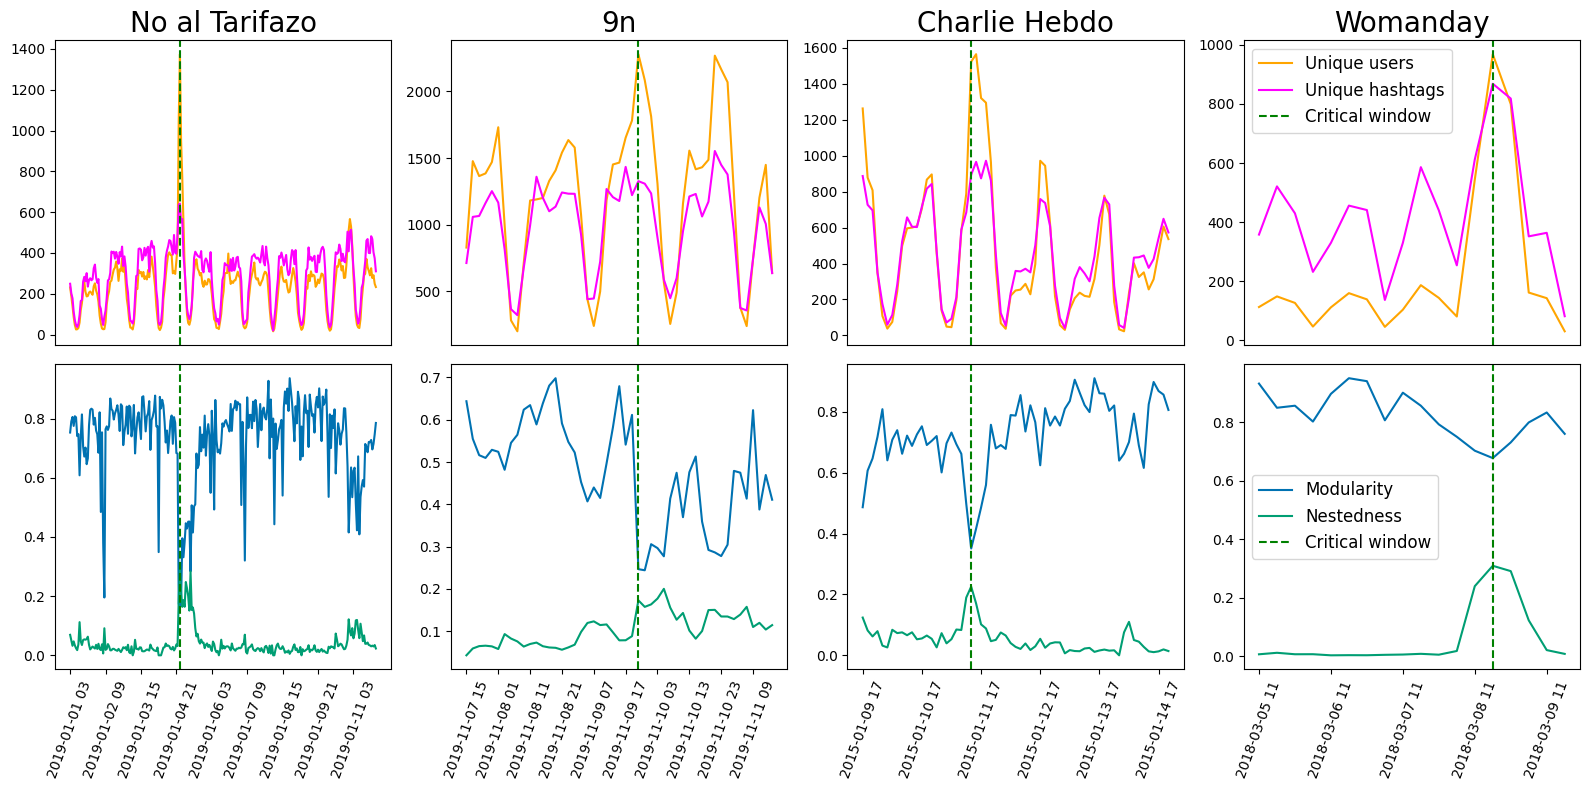

In [50]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 4)
axs = axs.flat
fig.set_size_inches(16,8)

for ax in axs:  # axs es una matriz, hay que aplanarla con .flat
    ax.set_facecolor("white")


axs[0].set_title("No al Tarifazo", fontsize=20)
axs[0].plot(hour_nat_dt, num_user_nat, label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_nat), 1)), color="orange")
axs[0].plot(hour_nat_dt, num_hashtag_nat, label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_nat), 1)), color="magenta")
axs[0].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[0].get_xaxis().set_visible(False)

axs[1].set_title("9n", fontsize=20)
axs[1].plot(hour_9n_dt, num_user_9n, label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_9n), 1)), color="orange")
axs[1].plot(hour_9n_dt, num_hashtag_9n, label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_9n), 1)), color="magenta")
axs[1].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[1].get_xaxis().set_visible(False)

axs[2].set_title("Charlie Hebdo", fontsize=20)
axs[2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], num_user_ch[lim_ch_und:lim_ch_sup], label="Número de usuarios únicos\nMedia de usuarios por hora: " +str(round(np.mean(num_user_ch[lim_ch_und:lim_ch_sup]), 1)), color="orange")
axs[2].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], num_hashtag_ch[lim_ch_und:lim_ch_sup], label="Número de hashtags únicos\nMedia de hashtags por hora: " +str(round(np.mean(num_hashtag_ch[lim_ch_und:lim_ch_sup]), 1)), color="magenta")
axs[2].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Fecha identificada como crítica: " + str(datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H")) +' (UTC)')
axs[2].get_xaxis().set_visible(False)


axs[3].set_title("Womanday", fontsize=20)
axs[3].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], num_user_wd[lim_wd_und:lim_wd_sup], label="Unique users", color="orange")
axs[3].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], num_hashtag_wd[lim_wd_und:lim_wd_sup], label="Unique hashtags", color="magenta")
axs[3].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Critical window")
axs[3].get_xaxis().set_visible(False)
axs[3].legend(loc="best", prop={'size': 12})   



axs[4].plot(hour_nat_dt, mod_sort_nat_h)
axs[4].plot(hour_nat_dt, nest_sort_nat_h)
axs[4].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_NAT)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[4].get_xaxis().set_visible(True)
axs[4].set_xticks(hour_nat_dt[::30])
axs[4].set_xticklabels(hour_nat_dt[::30])
axs[4].tick_params(axis='x', rotation=70)

axs[5].plot(hour_9n_dt, mod_sort_9n_h)
axs[5].plot(hour_9n_dt, nest_sort_9n_h)
axs[5].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_9N)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[5].get_xaxis().set_visible(True)
axs[5].set_xticks(hour_9n_dt[::5])
axs[5].set_xticklabels(hour_9n_dt[::5])
axs[5].tick_params(axis='x', rotation=70)

axs[6].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], mod_sort_ch_h[lim_ch_und:lim_ch_sup])
axs[6].plot(hour_ch_dt[lim_ch_und:lim_ch_sup], nest_sort_ch_h[lim_ch_und:lim_ch_sup])
axs[6].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_CH)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--")
axs[6].get_xaxis().set_visible(True)
axs[6].set_xticks(hour_ch_dt[lim_ch_und:lim_ch_sup:12])
axs[6].set_xticklabels(hour_ch_dt[lim_ch_und:lim_ch_sup:12])
axs[6].tick_params(axis='x', rotation=70)

axs[7].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], mod_sort_wd_h[lim_wd_und:lim_wd_sup], label="Modularity")
axs[7].plot(hour_wd_dt[lim_wd_und:lim_wd_sup], nest_sort_wd_h[lim_wd_und:lim_wd_sup], label="Nestedness")
axs[7].axvline(x=datetime.datetime.fromtimestamp(int(HORA_CRITICA_WD)*3600, tz=datetime.timezone.utc).strftime("%Y-%m-%d %H"), color="green", ls="--", label="Critical window")
axs[7].get_xaxis().set_visible(True)
axs[7].set_xticks(hour_wd_dt[lim_wd_und:lim_wd_sup:4])
axs[7].set_xticklabels(hour_wd_dt[lim_wd_und:lim_wd_sup:4])
axs[7].tick_params(axis='x', rotation=70)
axs[7].legend(loc="best", prop={'size': 12})


plt.tight_layout()
plt.savefig(plots_folder + "num_unique_users_coef_mod.png")
plt.show()


## Función de Distribución de Probabilidad (PDF) y Función de Distribución Cumulativa Complementaria (CCDF) de las horas críticas

In [51]:
#No al Tarifazo
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, read=False)

# 9n
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

# ch
plfit_ch, arr_pdf_points_ch, arr_ccdf_points_ch = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

# wd
plfit_wd, arr_pdf_points_wd, arr_ccdf_points_wd = calc_degree_distribution(HORA_CRITICA_WD, "wd/" + str(hour_window_wd) + '/', mode="h", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True)

100%|██████████| 1/1 [00:00<00:00, 102.20it/s]


Calculating best minimal value for power law fit
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  38.  40.  41.  42.  43.  44.  45.
  46.  50.  52.  54.  55.  56.  58.  59.  60.  68.  69.  73.  74.  83.
  94.  97. 105. 110. 112. 117. 131. 169. 174. 194. 209. 290. 433.]
[0.14695946 0.09459459 0.08445946 0.06587838 0.0472973  0.05236486
 0.04560811 0.04054054 0.02702703 0.05236486 0.02195946 0.02533784
 0.03378378 0.02533784 0.02195946 0.0152027  0.00844595 0.00337838
 0.01013514 0.01351351 0.00337838 0.00675676 0.00506757 0.00844595
 0.00168919 0.00168919 0.00506757 0.00168919 0.01182432 0.00168919
 0.01013514 0.00506757 0.00168919 0.00506757 0.00168919 0.00844595
 0.00168919 0.00506757 0.00337838 0.00337838 0.00675676 0.00337838
 0.00168919 0.00506757 0.00506757 0.00337838 0.00168919 0.00168919
 0.00168919 0.00168919 0.00168919 0.00168919 0.00168919 0.001689

100%|██████████| 1/1 [00:00<00:00, 44150.57it/s]


Calculating best minimal value for power law fit
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  54.  55.  56.  57.
  58.  59.  60.  61.  63.  64.  66.  67.  68.  69.  70.  71.  72.  73.
  75.  76.  77.  78.  79.  80.  81.  82.  84.  85.  86.  87.  88.  89.
  92.  93.  96.  97.  98. 100. 101. 102. 106. 108. 112. 115. 116. 118.
 119. 120. 121. 124. 125. 127. 129. 133. 135. 140. 143. 149. 150. 152.
 158. 159. 164. 172. 175. 179. 182. 184. 186. 191. 195. 197. 203. 205.
 208. 211. 216. 220. 230. 231. 245. 255. 261. 279. 289. 296. 297. 306.
 307. 317. 332. 349. 366. 381. 435. 456. 528. 574. 622. 651.]
[0.04467085 0.04623824 0.04467085 0.03526646 0.03918495 0.03056426
 0.04623824 0.04858934 0.04545455 0.01724138 0.02272727 0.02351097
 0.01645768 0.01567398 0.01253918 0.00940439 

100%|██████████| 1/1 [00:00<00:00, 35246.25it/s]


Calculating best minimal value for power law fit
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  36.  39.  40.  44.  46.  52.  53.  54.
  57.  76.  81.  95. 102. 153. 179. 264. 500.]
[0.13680387 0.14769976 0.13196126 0.09564165 0.08353511 0.06900726
 0.0496368  0.05569007 0.02179177 0.00968523 0.01089588 0.01210654
 0.02058111 0.00484262 0.01089588 0.00363196 0.01694915 0.00726392
 0.00363196 0.00484262 0.00605327 0.00242131 0.00242131 0.02784504
 0.02663438 0.00363196 0.00242131 0.00121065 0.00121065 0.00242131
 0.00121065 0.00121065 0.00242131 0.00121065 0.00121065 0.00121065
 0.00121065 0.00121065 0.00121065 0.00121065 0.00121065 0.00121065
 0.00121065 0.00121065 0.00121065 0.00121065 0.00121065 0.00121065
 0.00121065 0.00121065 0.00121065]
[0.13680387 0.28450363 0.41646489 0.51210654 0.59564165 0.66464891
 0.71428571 0.76997579 0.79176755 0.80145278 0.812348

100%|██████████| 1/1 [00:00<00:00, 34379.54it/s]

Calculating best minimal value for power law fit
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  21.  23.  24.  25.  33.  35.  45.  72. 695.]
[0.13768961 0.14819137 0.15402567 0.12835473 0.09334889 0.0630105
 0.07001167 0.0630105  0.01633606 0.00933489 0.01400233 0.00233372
 0.00350058 0.0210035  0.00116686 0.01283547 0.02450408 0.01750292
 0.00233372 0.00233372 0.00466744 0.00116686 0.00350058 0.00116686
 0.00116686 0.00116686 0.00116686 0.00116686]
[0.13768961 0.28588098 0.43990665 0.56826138 0.66161027 0.72462077
 0.79463244 0.85764294 0.873979   0.88331389 0.89731622 0.89964994
 0.90315053 0.92415403 0.92532089 0.93815636 0.96266044 0.98016336
 0.98249708 0.98483081 0.98949825 0.99066511 0.99416569 0.99533256
 0.99649942 0.99766628 0.99883314 1.        ]
[0.86231039 0.71411902 0.56009335 0.43173862 0.33838973 0.27537923
 0.20536756 0.14235706 0.126021   0.11668611 0.10268378 0.10035006
 0.09684947 0.07584597 0.07467911 0.06184364 0.

# AUTOSIMILITUD EN LAS REDES

## Grado medio por Kt

In [52]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat = {}
G_nat = nx.read_gexf(graphs_folder + "nodes_hashtag/nat/" + str(hour_window_nat) + '/' + HORA_CRITICA_NAT + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_nat.keys():
        # Se crea el subgrafo basandose en el threshold seleccionado
        F = thresh_normalization(G_nat,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_nat[threshold] = calc_avg_degree(F)


dict_hora_9n = {}
G_9n = nx.read_gexf(graphs_folder + "nodes_hashtag/9n/" + str(hour_window_9n) + '/' + HORA_CRITICA_9N + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_9n.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_9n,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_9n[threshold] = calc_avg_degree(F)


dict_hora_ch = {}
G_ch = nx.read_gexf(graphs_folder + "nodes_hashtag/ch/" + str(hour_window_ch) + '/' + HORA_CRITICA_CH + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_ch.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_ch,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_ch[threshold] = calc_avg_degree(F)

dict_hora_wd = {}
G_wd = nx.read_gexf(graphs_folder + "nodes_hashtag/wd/" + str(hour_window_wd) + '/' + HORA_CRITICA_WD + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_wd.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_wd,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_wd[threshold] = calc_avg_degree(F)

 36%|███▌      | 72/200 [00:00<00:00, 1288.77it/s]


## Autosimilitud

In [53]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500

# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/')
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/')
dict_thres_avg_clust_wd_h, dict_norm_int_deg_wd_h = calc_self_sim(HORA_CRITICA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/')

 14%|█▍        | 72/500 [00:00<00:00, 1175.80it/s]


In [54]:
limit_kt_nat = 35
limit_kt_9n = 60
limit_kt_ch = 25
limit_kt_wd = 18

arr_kt_plot_nat = [0,4,8,9,10,12,14,15,16,18,20]
arr_kt_plot_9n = [0,10,15,20,25,30,35,40]
arr_kt_plot_ch = [0,7,9,11,13,15]
#arr_kt_plot_ch = [5]
arr_kt_plot_wd = [0,4,6,8,10,12]

In [55]:
_, arr_deg_prob_nat, arr_deg_comp_cum_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_nat, exp=False, norm=True)
_, arr_deg_prob_9n, arr_deg_comp_cum_9n = calc_degree_distribution(HORA_CRITICA_9N,  "9n/" + str(hour_window_9n) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_9n, exp=False, norm=True)
_, arr_deg_prob_ch, arr_deg_comp_cum_ch = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch, exp=False, norm=True)
_, arr_deg_prob_wd, arr_deg_comp_cum_wd = calc_degree_distribution(HORA_CRITICA_WD,  "wd/" + str(hour_window_wd) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_wd, exp=False, norm=True)

100%|██████████| 11/11 [00:00<00:00, 174.72it/s]


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0,

100%|██████████| 8/8 [00:00<00:00, 813.97it/s]


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0,

100%|██████████| 6/6 [00:00<00:00, 1072.48it/s]


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,

100%|██████████| 6/6 [00:00<00:00, 1265.31it/s]


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,

In [20]:
def quitar_ceros(lista, indices):
    indices.sort(reverse=True)
    for indice in indices:
        if 0 <= indice < len(lista):
            del lista[indice]  
    return lista, indices

In [19]:
def calcular_quitar_ceros(lista):
    indices = []
    for indice, valor in enumerate(lista):
        if valor == float(0):
            indices.append(indice)
    return quitar_ceros(lista, indices)


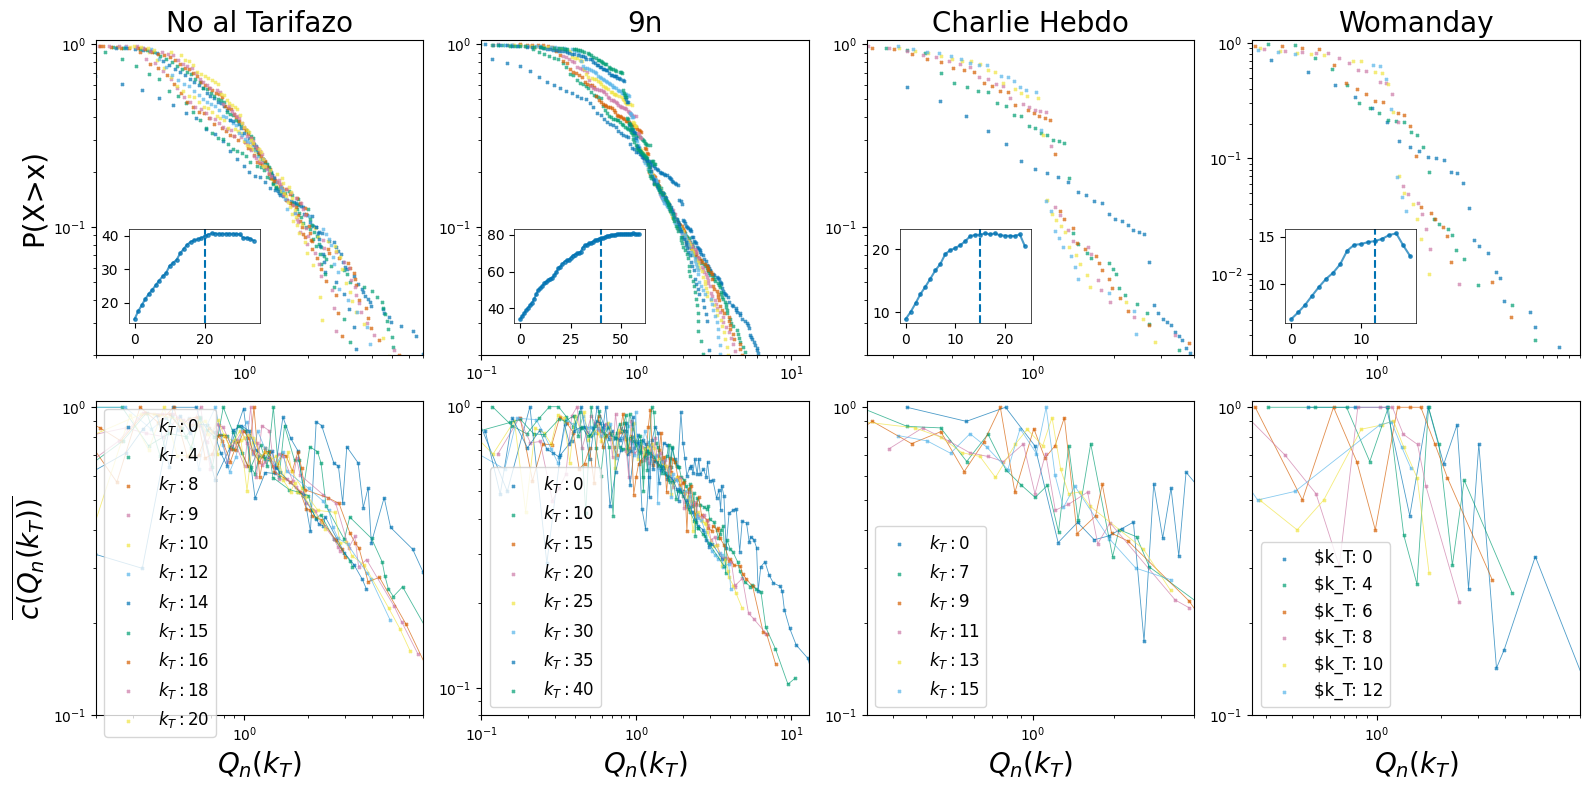

In [58]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 4)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,8)

xlim_nat = (0.2, 7)
xlim_9n = (0.1, 13)
xlim_ch = (0.24, 4)
xlim_wd = (0.26, 9)


dot_size=4
marker = "" \
"x"
alpha=0.7

for index, points in enumerate(arr_deg_comp_cum_nat):
    axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_nat[index]))
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(0.02, 1.05)
axs[0].set_xlim(xlim_nat[0], xlim_nat[1])
axs[0].set_title("No al Tarifazo", fontsize=20)
#axs[0].set_xlabel("")
axs[0].set_ylabel("P(X>x)", fontsize=20)


with plt.style.context('seaborn-v0_8-colorblind'):
    ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
    ax0_inset.set_facecolor('xkcd:white')
    for spine in ax0_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax0_inset.get_xaxis().set_visible(True)
    ax0_inset.plot(list(dict_hora_nat.keys())[0:limit_kt_nat], list(dict_hora_nat.values())[0:limit_kt_nat], alpha=alpha)
    ax0_inset.scatter(list(dict_hora_nat.keys())[0:limit_kt_nat], list(dict_hora_nat.values())[0:limit_kt_nat], s=6, alpha=alpha)
    ax0_inset.axvline(20, ls="--")
    #ax0_inset.set_ylabel("avg_deg")
    #ax0_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_deg_comp_cum_9n):
    axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_9n[index]))
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(0.02, 1.05)
axs[1].set_xlim(xlim_9n[0], xlim_9n[1])
axs[1].set_title("9n", fontsize=20)
#axs[1].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
    ax1_inset.set_facecolor('xkcd:white')
    for spine in ax1_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax1_inset.get_xaxis().set_visible(True)
    ax1_inset.plot(list(dict_hora_9n.keys())[0:limit_kt_9n], list(dict_hora_9n.values())[0:limit_kt_9n], alpha=alpha)
    ax1_inset.scatter(list(dict_hora_9n.keys())[0:limit_kt_9n], list(dict_hora_9n.values())[0:limit_kt_9n], s=6, alpha=alpha)
    ax1_inset.axvline(40, ls="--")
    #ax1_inset.set_ylabel("avg_deg")
    #ax1_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_deg_comp_cum_ch):
    axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_ch[index]))
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_ylim(0.02, 1.05)
axs[2].set_xlim(xlim_ch[0], xlim_ch[1])
axs[2].set_title("Charlie Hebdo", fontsize=20)
#axs[2].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
    ax2_inset.set_facecolor('xkcd:white')
    for spine in ax2_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax2_inset.get_xaxis().set_visible(True)
    ax2_inset.plot(list(dict_hora_ch.keys())[0:limit_kt_ch], list(dict_hora_ch.values())[0:limit_kt_ch], alpha=alpha)
    ax2_inset.scatter(list(dict_hora_ch.keys())[0:limit_kt_ch], list(dict_hora_ch.values())[0:limit_kt_ch], s=6, alpha=alpha)
    ax2_inset.axvline(15, ls="--")
    #ax2_inset.set_ylabel("avg_deg")
    #ax2_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_deg_comp_cum_wd):
    axs[3].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_wd[index]))
axs[3].set_xscale('log')
axs[3].set_yscale('log')
axs[3].set_ylim(0.002, 1.05)
axs[3].set_xlim(xlim_wd[0], xlim_wd[1])
axs[3].set_title("Womanday", fontsize=20)
#axs[3].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax3_inset = axs[3].inset_axes([0.1, 0.1, 0.4, 0.3])
    ax3_inset.set_facecolor('xkcd:white')
    for spine in ax3_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax3_inset.get_xaxis().set_visible(True)
    ax3_inset.plot(list(dict_hora_wd.keys())[0:limit_kt_wd], list(dict_hora_wd.values())[0:limit_kt_wd], alpha=alpha)
    ax3_inset.scatter(list(dict_hora_wd.keys())[0:limit_kt_wd], list(dict_hora_wd.values())[0:limit_kt_wd], s=6, alpha=alpha)
    ax3_inset.axvline(12, ls="--")
    #ax3_inset.set_ylabel("avg_deg")
    #ax3_inset.set_xlabel("$K_t$")





for index, kt in enumerate(arr_kt_plot_nat[:]):
    if kt in dict_norm_int_deg_nat_h.keys():
        points_x = list(dict_norm_int_deg_nat_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_nat_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[4].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[4].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[4].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[4].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[4].set_xscale('log')  
axs[4].set_yscale('log')      
axs[4].set_ylim(0.1, 1.05)
axs[4].set_xlim(xlim_nat[0], xlim_nat[1])
axs[4].legend(prop={'size': 12})


for index, kt in enumerate(arr_kt_plot_9n[:]):
    if kt in dict_norm_int_deg_9n_h.keys():
        points_x = list(dict_norm_int_deg_9n_h[kt].keys())[::2]
        points_y = list(dict_norm_int_deg_9n_h[kt].values())[::2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[5].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[5].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[5].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[5].set_xscale('log')  
axs[5].set_yscale('log')      
axs[5].set_ylim(0.08, 1.05)
axs[5].set_xlim(xlim_9n[0], xlim_9n[1])

axs[5].legend(prop={'size': 12})


for index, kt in enumerate(arr_kt_plot_ch[:]):
    if kt in dict_norm_int_deg_ch_h.keys():
        points_x = list(dict_norm_int_deg_ch_h[kt].keys())[:-1:2]
        points_y = list(dict_norm_int_deg_ch_h[kt].values())[:-1:2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_ch_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[6].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[6].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[6].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[6].set_xscale('log')  
axs[6].set_yscale('log')          
axs[6].set_ylim(0.1, 1.05)
axs[6].set_xlim(xlim_ch[0], xlim_ch[1])
axs[6].legend(prop={'size': 12})


for index, kt in enumerate(arr_kt_plot_wd[:]):
    if kt in dict_norm_int_deg_wd_h.keys():
        points_x = list(dict_norm_int_deg_wd_h[kt].keys())[:-1:2]
        points_y = list(dict_norm_int_deg_wd_h[kt].values())[:-1:2]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_wd_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[7].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[7].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}')        

axs[7].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[7].set_xscale('log')  
axs[7].set_yscale('log')      
axs[7].legend(loc="lower left", prop={'size': 12})
axs[7].set_ylim(0.1, 1.05)
axs[7].set_xlim(xlim_wd[0], xlim_wd[1])

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper.png")
plt.show()

## Uso de d-mercator

Los archivos de código relativos al uso de d-mercator se encuentran en la carpeta ```d-mercator/``` del presente repositorio.

## Grafos Filtrados

### Ajuste a ley de potencia de los grafos filtrados

In [10]:
def write_filtered_graph(MANIFESTACION, HORA_CRITICA, umbral, hour_window=1):

    # 9n
    G = nx.read_gexf(graphs_folder + "nodes_hashtag/" + MANIFESTACION + '/' + str(hour_window) + '/' + HORA_CRITICA + ".gexf")
    nodos_original = G.number_of_nodes()
    aristas_original = G.number_of_edges()
    # Se queda con las aristas con peso mayor o igual a umbral
    G = create_filtered_graph(G, umbral)

    # Componente gigante del grafo
    Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
    G = G.subgraph(Gcc[0])

    nx.write_gexf(G, graphs_folder + "filtered/" + str(umbral) + '/'  + MANIFESTACION + '/' + str(hour_window) + '/' + HORA_CRITICA + ".gexf")

    # Escribimos el .edge (listo para usar dmercator)
    with open(graphs_folder + "filtered/" + str(umbral) + '/'  + MANIFESTACION + '/' + str(hour_window) + '/' + HORA_CRITICA + ".edge", "w") as f:
        for edge in G.edges():
            f.write(edge[0] + ' ' + edge[1] + '\n')
    print("Grafo", MANIFESTACION + ":" + HORA_CRITICA," (umbral", str(umbral) + ')', "reducido a", round(G.number_of_nodes()/nodos_original*100,2), "% en nodos y ", round(G.number_of_edges()/aristas_original*100, 2), "% en aristas.")

In [642]:
# Threshold empleado para cada manifestacion
umbral_nat = 5
umbral_9n = 5
umbral_ch = 3
umbral_wd = 2

umbral_otro_nat = 1
umbral_otro_9n = 3
umbral_otro_ch = 2
umbral_otro_wd = 3

In [643]:
hour_window_nat, hour_window_9n, hour_window_ch, hour_window_wd

(1, 2, 2, 6)

In [644]:
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH, HORA_CRITICA_WD

('429624', '437037', '394717', '422369')

In [645]:
OTRA_HORA_NAT = "429600"
OTRA_HORA_9N = "437000"
OTRA_HORA_CH = "394628"
"""OTRA_HORA_WD = "422303"""

'OTRA_HORA_WD = "422303'

In [646]:
# CREACIÓN DE LOS GRAFOS FILTRADOS

write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, hour_window_ch)
"""write_filtered_graph("wd", HORA_CRITICA_WD, umbral_wd, hour_window_wd)"""

Grafo nat:429624  (umbral 5) reducido a 13.08 % en nodos y  9.02 % en aristas.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos y  7.1 % en aristas.
Grafo ch:394717  (umbral 3) reducido a 13.31 % en nodos y  7.4 % en aristas.


'write_filtered_graph("wd", HORA_CRITICA_WD, umbral_wd, hour_window_wd)'

In [647]:
# CREACIÓN DE LOS GRAFOS FILTRADOS DE OTRAS HORAS NO CRITICAS

write_filtered_graph("nat", OTRA_HORA_NAT, umbral_otro_nat, hour_window_nat)
write_filtered_graph("9n", OTRA_HORA_9N, umbral_otro_9n, hour_window_9n)
write_filtered_graph("ch", OTRA_HORA_CH, umbral_otro_ch, hour_window_ch)
"""write_filtered_graph("wd", OTRA_HORA_WD, umbral_otro_wd, hour_window_wd)"""

Grafo nat:429600  (umbral 1) reducido a 47.71 % en nodos y  79.71 % en aristas.
Grafo 9n:437000  (umbral 3) reducido a 9.13 % en nodos y  2.67 % en aristas.
Grafo ch:394628  (umbral 2) reducido a 25.64 % en nodos y  26.46 % en aristas.


'write_filtered_graph("wd", OTRA_HORA_WD, umbral_otro_wd, hour_window_wd)'

### Grado medio por kt

In [648]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat = {}
G_nat = nx.read_gexf(graphs_folder + f"filtered/{umbral_nat}/nat/" + str(hour_window_nat) + '/' + HORA_CRITICA_NAT + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_nat.keys():
        # Se crea el subgrafo basandose en el threshold seleccionado
        F = thresh_normalization(G_nat,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_nat[threshold] = calc_avg_degree(F)

dict_otra_hora_nat = {}
G_nat = nx.read_gexf(graphs_folder + f"filtered/{umbral_otro_nat}/nat/" + str(hour_window_nat) + '/' + OTRA_HORA_NAT + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_otra_hora_nat.keys():
        # Se crea el subgrafo basandose en el threshold seleccionado
        F = thresh_normalization(G_nat,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_otra_hora_nat[threshold] = calc_avg_degree(F)


dict_hora_9n = {}
G_9n = nx.read_gexf(graphs_folder + f"filtered/{umbral_9n}/9n/" + str(hour_window_9n) + '/' + HORA_CRITICA_9N + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_9n.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_9n,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_9n[threshold] = calc_avg_degree(F)


dict_otra_hora_9n = {}
G_9n = nx.read_gexf(graphs_folder + f"filtered/{umbral_otro_9n}/9n/" + str(hour_window_9n) + '/' + OTRA_HORA_9N + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_otra_hora_9n.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_9n,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_otra_hora_9n[threshold] = calc_avg_degree(F)


dict_hora_ch = {}
G_ch = nx.read_gexf(graphs_folder + f"filtered/{umbral_ch}/ch/" + str(hour_window_ch) + '/' + HORA_CRITICA_CH + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_hora_ch.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_ch,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_hora_ch[threshold] = calc_avg_degree(F)


dict_otra_hora_ch = {}
G_ch = nx.read_gexf(graphs_folder + f"filtered/{umbral_otro_ch}/ch/" + str(hour_window_ch) + '/' + OTRA_HORA_CH + '.gexf')
arr_medium_deg = []
for threshold in tqdm(range(MAX_UMBRAL)):
    threshold = float(threshold)
    if not threshold in dict_otra_hora_ch.keys():
        # Se crea el subgrafo basándonos en el threshold seleccionado
        F = thresh_normalization(G_ch,  threshold)
        if F == -1:
            # Caso de grafo vacío o grafo inconexo
            break 
        dict_otra_hora_ch[threshold] = calc_avg_degree(F)



  0%|          | 0/200 [00:00<?, ?it/s]

 76%|███████▌  | 151/200 [00:00<00:00, 4114.25it/s]


In [654]:
limit_kt_nat = 35
limit_kt_9n = 60
limit_kt_ch = 30
limit_kt_wd = 18

critical_kt_nat = 10
critical_kt_9n = 18
critical_kt_ch = 5
critical_kt_wd = 7

arr_kt_plot_nat = [0,1,2,3,4,5,6,7,8,9,10]
arr_kt_plot_9n = [0,2,4,6,8,10,12,14,16,18]
arr_kt_plot_ch = [0,1,2,3,4,5]
arr_kt_plot_wd = [0,1,2,3,4,5,6,7]


critical_otra_kt_nat = 10
critical_otra_kt_9n = 18
critical_otra_kt_ch = 5

arr_otra_kt_plot_nat = [0,2,4,6,8,10,12,14,16,18]
arr_otra_kt_plot_9n = [0,1,2,3,4,5]
arr_otra_kt_plot_ch =  [0,1,2,3,4,5,6,7,8,9,10]

In [669]:
plfit_nat, arr_pdf_points_nat, arr_ccdf_points_nat = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat, thresh_filt=umbral_nat, norm=True)
plfit_9n, arr_pdf_points_9n, arr_ccdf_points_9n = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n, thresh_filt=umbral_9n, norm=True)
plfit_ch, arr_pdf_points_ch, arr_ccdf_points_ch = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch, thresh_filt=umbral_ch, norm=True)
"""plfit_wd, arr_pdf_points_wd, arr_ccdf_points_wd = calc_degree_distribution(HORA_CRITICA_WD, "wd/" + str(hour_window_wd) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_wd, thresh_filt=umbral_wd, norm=True)"""

plfit_otra_nat, arr_pdf_points_otra_nat, arr_ccdf_points_otra_nat = calc_degree_distribution(OTRA_HORA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_nat, thresh_filt=umbral_otro_nat, norm=True)
plfit_otra_9n, arr_pdf_points_otra_9n, arr_ccdf_points_otra_9n = calc_degree_distribution(OTRA_HORA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_9n, thresh_filt=umbral_otro_9n, norm=True)
plfit_otra_ch, arr_pdf_points_otra_ch, arr_ccdf_points_otra_ch = calc_degree_distribution(OTRA_HORA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_ch, thresh_filt=umbral_otro_ch, norm=True)
"""plfit_otra_wd, arr_pdf_points_otra_wd, arr_ccdf_points_otra_wd = calc_degree_distribution(OTRA_HORA_WD, "wd/" + str(hour_window_wd) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_wd, thresh_filt=umbral_otro_wd, norm=True)"""

100%|██████████| 11/11 [00:00<00:00, 31622.58it/s]


Calculating best minimal value for power law fit


100%|██████████| 10/10 [00:00<00:00, 42711.85it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 69905.07it/s]


...

100%|██████████| 6/6 [00:00<00:00, 77195.78it/s]


Calculating best minimal value for power law fit


100%|██████████| 11/11 [00:00<00:00, 52909.80it/s]

Calculating best minimal value for power law fit


'plfit_otra_wd, arr_pdf_points_otra_wd, arr_ccdf_points_otra_wd = calc_degree_distribution(OTRA_HORA_WD, "wd/" + str(hour_window_wd) + \'/\', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_otra_kt_plot_wd, thresh_filt=umbral_otro_wd, norm=True)'

### Autosimilitud de redes filtradas y Resultados en otras ventanas temporales diferentes a la crítica

In [656]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)
"""dict_thres_avg_clust_wd_h, dict_norm_int_deg_wd_h = calc_self_sim(HORA_CRITICA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/', mode="f", thresh_filter=umbral_wd)"""


dict_thres_avg_clust_otra_nat_h, dict_norm_int_deg_otra_nat_h = calc_self_sim(OTRA_HORA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_otro_nat)
dict_thres_avg_clust_otra_9n_h, dict_norm_int_deg_otra_9n_h = calc_self_sim(OTRA_HORA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_otro_9n)
dict_thres_avg_clust_otra_ch_h, dict_norm_int_deg_otra_ch_h = calc_self_sim(OTRA_HORA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_otro_ch)
"""dict_thres_avg_clust_otra_wd_h, dict_norm_int_deg_otra_wd_h = calc_self_sim(OTRA_HORA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + '/', mode="f", thresh_filter=umbral_otro_wd)"""

 30%|███       | 151/500 [00:00<00:00, 1213.31it/s]


'dict_thres_avg_clust_otra_wd_h, dict_norm_int_deg_otra_wd_h = calc_self_sim(OTRA_HORA_WD, MAX_UMBRAL, "wd/" + str(hour_window_wd) + \'/\', mode="f", thresh_filter=umbral_otro_wd)'

In [687]:
def get_exp_from_pdf(pdf_points):
    x_vals = []
    probabilities = []
    for elem in pdf_points:
    # Extraer los valores de x y las probabilidades
        for a in np.array([point[0] for point in elem]):
            x_vals.append(a)
        for b in np.array([point[1] for point in elem]):
            probabilities.append(b)

    # num total de observaciones que deseas simular
    total_count = 1000  

    # Calcular las frecuencias absolutas
    frequencies = probabilities * total_count

    # Reconstruir los datos originales
    data = []
    for x, freq in zip(x_vals, frequencies):
        count = int(round(freq))
        data.extend([x] * count)
    import powerlaw

    fit = powerlaw.Fit(data)
    alpha = fit.power_law.alpha
    xmin = fit.power_law.xmin

    return alpha

In [688]:
print("Alpha NAT: ", get_exp_from_pdf(arr_pdf_points_nat))
print("Alpha 9n: ", get_exp_from_pdf(arr_pdf_points_9n))
print("Alpha ch: ", get_exp_from_pdf(arr_pdf_points_ch))

Calculating best minimal value for power law fit
Alpha NAT:  5.204913863780603
Calculating best minimal value for power law fit
Alpha 9n:  12.081365269850957
Calculating best minimal value for power law fit
Alpha ch:  1483.9997752304696


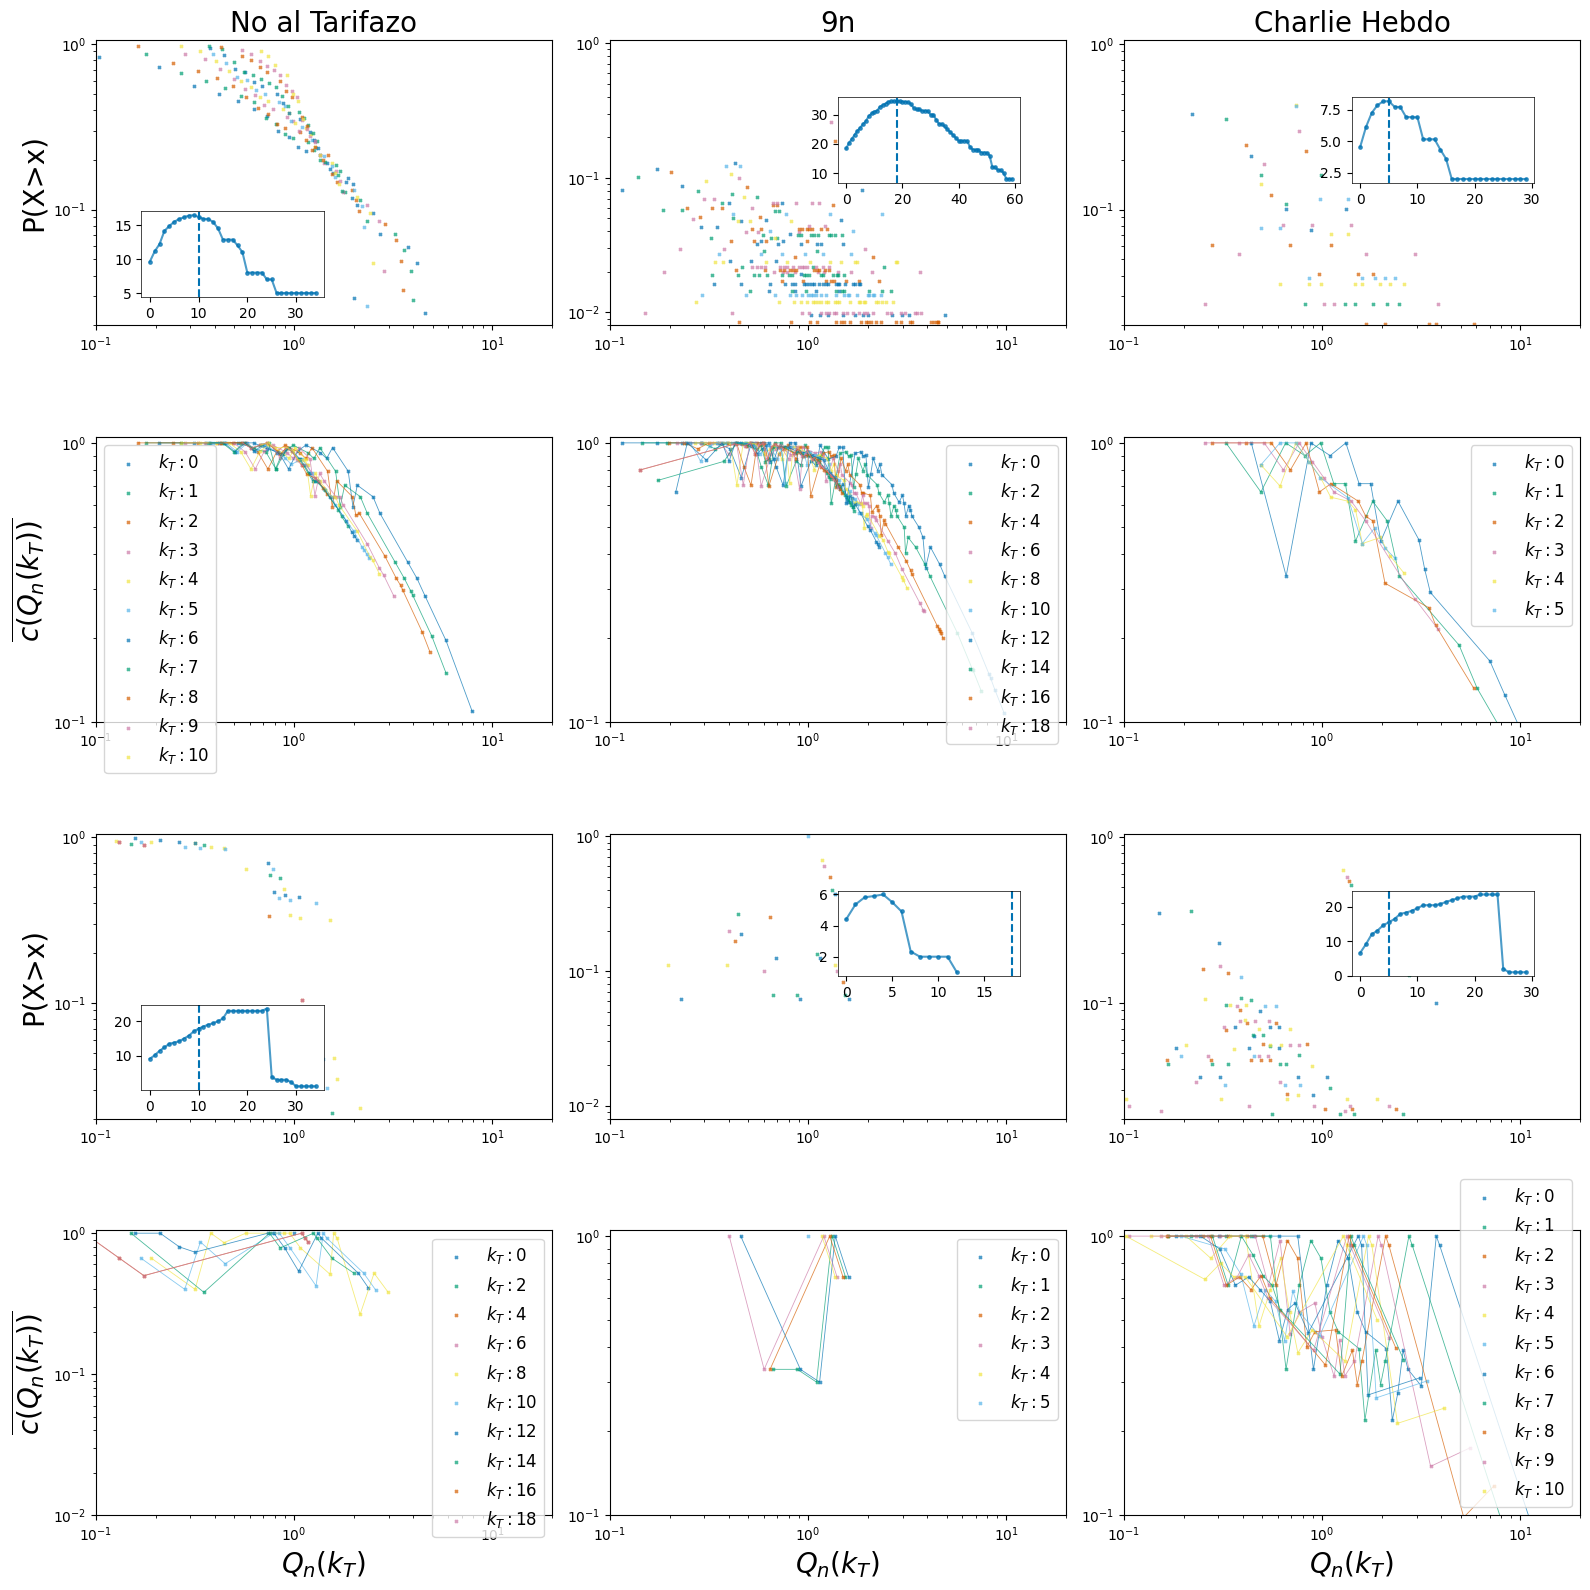

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 3)
axs = axs.flat
for ax in axs:  
    ax.set_facecolor("white")
fig.set_size_inches(16,16)

xlim_nat = (0.1, 20)
xlim_9n = (0.1, 20)
xlim_ch = (0.1, 20)
xlim_wd = (0.1, 20)

xlim_otra_nat = (0.1, 20)
xlim_otra_9n = (0.1, 20)
xlim_otra_ch = (0.1, 20)
xlim_otra_wd = (0.1, 20)


dot_size=4
marker = "" \
"x"
alpha=0.7

array_puntos_plfit = []

for index, points in enumerate(arr_ccdf_points_nat):
    axs[0].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_nat[index]))
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(0.02, 1.05)
axs[0].set_xlim(xlim_nat[0], xlim_nat[1])
axs[0].set_title("No al Tarifazo", fontsize=20)
#axs[0].set_xlabel("")
axs[0].set_ylabel("P(X>x)", fontsize=20)


with plt.style.context('seaborn-v0_8-colorblind'):
    ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
    ax0_inset.set_facecolor('xkcd:white')
    for spine in ax0_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax0_inset.get_xaxis().set_visible(True)
    ax0_inset.plot(list(dict_hora_nat.keys())[0:limit_kt_nat], list(dict_hora_nat.values())[0:limit_kt_nat], alpha=alpha)
    ax0_inset.scatter(list(dict_hora_nat.keys())[0:limit_kt_nat], list(dict_hora_nat.values())[0:limit_kt_nat], s=6, alpha=alpha)
    ax0_inset.axvline(critical_kt_nat, ls="--")
    #ax0_inset.set_ylabel("avg_deg")
    #ax0_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_pdf_points_9n):
    axs[1].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_9n[index]))
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(0.008, 1.05)
axs[1].set_xlim(xlim_9n[0], xlim_9n[1])
axs[1].set_title("9n", fontsize=20)
#axs[1].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax1_inset = axs[1].inset_axes([0.5, 0.5, 0.4, 0.3])
    ax1_inset.set_facecolor('xkcd:white')
    for spine in ax1_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax1_inset.get_xaxis().set_visible(True)
    ax1_inset.plot(list(dict_hora_9n.keys())[0:limit_kt_9n], list(dict_hora_9n.values())[0:limit_kt_9n], alpha=alpha)
    ax1_inset.scatter(list(dict_hora_9n.keys())[0:limit_kt_9n], list(dict_hora_9n.values())[0:limit_kt_9n], s=6, alpha=alpha)
    ax1_inset.axvline(critical_kt_9n, ls="--")
    #ax1_inset.set_ylabel("avg_deg")
    #ax1_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_pdf_points_ch):
    axs[2].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_ch[index]))
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_ylim(0.02, 1.05)
axs[2].set_xlim(xlim_ch[0], xlim_ch[1])
axs[2].set_title("Charlie Hebdo", fontsize=20)
#axs[2].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax2_inset = axs[2].inset_axes([0.5, 0.5, 0.4, 0.3])
    ax2_inset.set_facecolor('xkcd:white')
    for spine in ax2_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax2_inset.get_xaxis().set_visible(True)
    ax2_inset.plot(list(dict_hora_ch.keys())[0:limit_kt_ch], list(dict_hora_ch.values())[0:limit_kt_ch], alpha=alpha)
    ax2_inset.scatter(list(dict_hora_ch.keys())[0:limit_kt_ch], list(dict_hora_ch.values())[0:limit_kt_ch], s=6, alpha=alpha)
    ax2_inset.axvline(critical_kt_ch, ls="--")
    #ax2_inset.set_ylabel("avg_deg")
    #ax2_inset.set_xlabel("$K_t$")

"""for index, points in enumerate(arr_pdf_points_wd):
    axs[3].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_kt_plot_wd[index]))
axs[3].set_xscale('log')
axs[3].set_yscale('log')
axs[3].set_ylim(0.001, 1.05)
axs[3].set_xlim(xlim_wd[0], xlim_wd[1])
axs[3].set_title("Womanday", fontsize=20)
#axs[3].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax3_inset = axs[3].inset_axes([0.5, 0.5, 0.4, 0.3])
    ax3_inset.set_facecolor('xkcd:white')
    for spine in ax3_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax3_inset.get_xaxis().set_visible(True)
    ax3_inset.plot(list(dict_hora_wd.keys())[0:limit_kt_wd], list(dict_hora_wd.values())[0:limit_kt_wd], alpha=alpha)
    ax3_inset.scatter(list(dict_hora_wd.keys())[0:limit_kt_wd], list(dict_hora_wd.values())[0:limit_kt_wd], s=6, alpha=alpha)
    ax3_inset.axvline(critical_kt_wd, ls="--")
    #ax3_inset.set_ylabel("avg_deg")
    #ax3_inset.set_xlabel("$K_t$")"""





for index, kt in enumerate(arr_kt_plot_nat[:]):
    if kt in dict_norm_int_deg_nat_h.keys():
        points_x = list(dict_norm_int_deg_nat_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_nat_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[3].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[3].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[3].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[3].set_xscale('log')  
axs[3].set_yscale('log')      
axs[3].set_ylim(0.1, 1.05)
axs[3].set_xlim(xlim_nat[0], xlim_nat[1])
axs[3].legend(prop={'size': 12})


for index, kt in enumerate(arr_kt_plot_9n[:]):
    if kt in dict_norm_int_deg_9n_h.keys():
        points_x = list(dict_norm_int_deg_9n_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_9n_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[4].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[4].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[4].set_xscale('log')  
axs[4].set_yscale('log')      
axs[4].set_ylim(0.1, 1.05)
axs[4].set_xlim(xlim_9n[0], xlim_9n[1])

axs[4].legend(prop={'size': 12})


for index, kt in enumerate(arr_kt_plot_ch[:]):
    if kt in dict_norm_int_deg_ch_h.keys():
        points_x = list(dict_norm_int_deg_ch_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_ch_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_ch_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[5].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[5].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[5].set_xscale('log')  
axs[5].set_yscale('log')          
axs[5].set_ylim(0.1, 1.05)
axs[5].set_xlim(xlim_ch[0], xlim_ch[1])
axs[5].legend(prop={'size': 12})


"""for index, kt in enumerate(arr_kt_plot_wd[:]):
    if kt in dict_norm_int_deg_wd_h.keys():
        points_x = list(dict_norm_int_deg_wd_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_wd_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_wd_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[7].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[7].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[7].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[7].set_xscale('log')  
axs[7].set_yscale('log')      
axs[7].legend(loc="lower left", prop={'size': 12})
axs[7].set_ylim(0.1, 1.05)
axs[7].set_xlim(xlim_wd[0], xlim_wd[1])"""


for index, points in enumerate(arr_ccdf_points_otra_nat):
    axs[6].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_otra_kt_plot_nat[index]))
axs[6].set_xscale('log')
axs[6].set_yscale('log')
axs[6].set_ylim(0.02, 1.05)
axs[6].set_xlim(xlim_otra_nat[0], xlim_otra_nat[1])
#axs[0].set_xlabel("")
axs[6].set_ylabel("P(X>x)", fontsize=20)


with plt.style.context('seaborn-v0_8-colorblind'):
    ax6_inset = axs[6].inset_axes([0.1, 0.1, 0.4, 0.3])
    ax6_inset.set_facecolor('xkcd:white')
    for spine in ax6_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax6_inset.get_xaxis().set_visible(True)
    ax6_inset.plot(list(dict_otra_hora_nat.keys())[0:limit_kt_nat], list(dict_otra_hora_nat.values())[0:limit_kt_nat], alpha=alpha)
    ax6_inset.scatter(list(dict_otra_hora_nat.keys())[0:limit_kt_nat], list(dict_otra_hora_nat.values())[0:limit_kt_nat], s=6, alpha=alpha)
    ax6_inset.axvline(critical_otra_kt_nat, ls="--")
    #ax6_inset.set_ylabel("avg_deg")
    #ax6_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_pdf_points_otra_9n):
    axs[7].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_otra_kt_plot_9n[index]))
axs[7].set_xscale('log')
axs[7].set_yscale('log')
axs[7].set_ylim(0.008, 1.05)
axs[7].set_xlim(xlim_otra_9n[0], xlim_otra_9n[1])
#axs[1].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax7_inset = axs[7].inset_axes([0.5, 0.5, 0.4, 0.3])
    ax7_inset.set_facecolor('xkcd:white')
    for spine in ax7_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax7_inset.get_xaxis().set_visible(True)
    ax7_inset.plot(list(dict_otra_hora_9n.keys())[0:limit_kt_9n], list(dict_otra_hora_9n.values())[0:limit_kt_9n], alpha=alpha)
    ax7_inset.scatter(list(dict_otra_hora_9n.keys())[0:limit_kt_9n], list(dict_otra_hora_9n.values())[0:limit_kt_9n], s=6, alpha=alpha)
    ax7_inset.axvline(critical_otra_kt_9n, ls="--")
    #ax7_inset.set_ylabel("avg_deg")
    #ax7_inset.set_xlabel("$K_t$")

for index, points in enumerate(arr_pdf_points_otra_ch):
    axs[8].scatter(points[0], points[1], marker=marker, s=dot_size, alpha=alpha, label="K_T = " + str(arr_otra_kt_plot_ch[index]))
axs[8].set_xscale('log')
axs[8].set_yscale('log')
axs[8].set_ylim(0.02, 1.05)
axs[8].set_xlim(xlim_otra_ch[0], xlim_otra_ch[1])
#axs[2].set_xlabel("")
with plt.style.context('seaborn-v0_8-colorblind'):
    ax8_inset = axs[8].inset_axes([0.5, 0.5, 0.4, 0.3])
    ax8_inset.set_facecolor('xkcd:white')
    for spine in ax8_inset.spines.values():
        spine.set_visible(True)  # Asegurar que sea visible
        spine.set_linewidth(0.5)   # Grosor del borde (opcional)
        spine.set_color("black") 
    ax8_inset.get_xaxis().set_visible(True)
    ax8_inset.plot(list(dict_otra_hora_ch.keys())[0:limit_kt_ch], list(dict_otra_hora_ch.values())[0:limit_kt_ch], alpha=alpha)
    ax8_inset.scatter(list(dict_otra_hora_ch.keys())[0:limit_kt_ch], list(dict_otra_hora_ch.values())[0:limit_kt_ch], s=6, alpha=alpha)
    ax8_inset.axvline(critical_otra_kt_ch, ls="--")
    #ax8_inset.set_ylabel("avg_deg")
    #ax8_inset.set_xlabel("$K_t$")



for index, kt in enumerate(arr_otra_kt_plot_nat[:]):
    if kt in dict_norm_int_deg_otra_nat_h.keys():
        points_x = list(dict_norm_int_deg_otra_nat_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_otra_nat_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_otra_nat_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[9].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[9].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[9].set_ylabel("$\\overline{c(Q_n(k_T))}$", fontsize=20)
axs[9].set_xlabel("$Q_n(k_T)$", fontsize=20)
axs[9].set_xscale('log')  
axs[9].set_yscale('log')      
axs[9].set_ylim(0.01, 1.05)
axs[9].set_xlim(xlim_otra_nat[0], xlim_otra_nat[1])
axs[9].legend(prop={'size': 12})


for index, kt in enumerate(arr_otra_kt_plot_9n[:]):
    if kt in dict_norm_int_deg_otra_9n_h.keys():
        points_x = list(dict_norm_int_deg_otra_9n_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_otra_9n_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_otra_9n_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[10].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[10].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[10].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[10].set_xscale('log')  
axs[10].set_yscale('log')      
axs[10].set_ylim(0.1, 1.05)
axs[10].set_xlim(xlim_otra_9n[0], xlim_otra_9n[1])

axs[10].legend(prop={'size': 12})


for index, kt in enumerate(arr_otra_kt_plot_ch[:]):
    if kt in dict_norm_int_deg_otra_ch_h.keys():
        points_x = list(dict_norm_int_deg_otra_ch_h[kt].keys())[::]
        points_y = list(dict_norm_int_deg_otra_ch_h[kt].values())[::]
        # Se quita el 0 para que la visualizacións se más clara
        if float(0) in dict_norm_int_deg_otra_ch_h[kt].keys():
            points_x = points_x[1:]
            points_y = points_y[1:]

        points_y, indexes = calcular_quitar_ceros(points_y)
        points_x, _ = quitar_ceros(points_x, indexes)
 
        axs[11].plot(points_x, points_y, alpha=alpha, linewidth=0.6)
        axs[11].scatter(points_x, points_y, alpha=alpha, s=4, marker=marker, label=f'$k_T: {kt}$')        

axs[11].set_xlabel("$Q_n(k_T$)", fontsize=20)
axs[11].set_xscale('log')  
axs[11].set_yscale('log')          
axs[11].set_ylim(0.1, 1.05)
axs[11].set_xlim(xlim_otra_ch[0], xlim_otra_ch[1])
axs[11].legend(prop={'size': 12})




plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

 Ahora hacer 
```cd d-mercator/``` (en la acarpeta self--similarity)

```sudo python3 run_dmercator_docker.py -i ../poster_cs3/github/self-similarity-in-social-movements/graphs/filtered/3/ch/2/394718.edge -d 1 -v ../poster_cs3/github/self-similarity-in-social-movements/graphs/filtered/3/ch/2/394718.edge```

y, una vez generado los archivos,
ejecutar 

```python3 pdf_d-mercator.py graphs/filtered/3/ch/2/394718.edge```